# Flat bands from the `extkag_1_*_shb.csv` simulations

Extract the 14 lowest-frequency bands from every matching COMSOL CSV export. The highest-frequency retained band is treated as the flat band.

In [14]:
import csv
import re
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

## Discover the simulation files

In [15]:
# The first path is correct when the notebook runs from its own directory;
# the second also permits execution from the repository root.
data_dir = next(
    path.resolve()
    for path in (Path('../../../data/simulation'), Path('data/simulation'))
    if path.is_dir()
)

filename_pattern = re.compile(r'^extkag_1(.+)shb\.csv$')
band_files = {}

for csv_path in data_dir.glob('extkag_1*shb.csv'):
    match = filename_pattern.match(csv_path.name)
    if match is None:
        continue

    label = match.group(1)
    if label in band_files:
        raise ValueError(f'Multiple files found for {label!r}')
    band_files[label] = csv_path

band_files = dict(sorted(band_files.items()))
if not band_files:
    raise FileNotFoundError(
        f'No extkag_1_*_shb.csv files found in {data_dir}'
    )

print(f'Found {len(band_files)} band-structure files:')
for label, csv_path in band_files.items():
    print(f'  {label}: {csv_path.name}')

Found 6 band-structure files:
  _: extkag_1_shb.csv
  _coarse_: extkag_1_coarse_shb.csv
  _face_union_: extkag_1_face_union_shb.csv
  _face_union_lattice_: extkag_1_face_union_lattice_shb.csv
  _fine_: extkag_1_fine_shb.csv
  _normal_new_: extkag_1_normal_new_shb.csv


## Extract and organize the 14 lowest eigenfrequency bands

In [16]:
BAND_COUNT = 14

UNIT_TO_HZ = {
    'hz': 1.0,
    'khz': 1.0e3,
    'mhz': 1.0e6,
    'ghz': 1.0e9,
}


def frequency_scale_to_hz(column_name):
    normalized = column_name.casefold().replace(' ', '')
    for unit, scale in UNIT_TO_HZ.items():
        if f'({unit})' in normalized:
            return scale
    raise ValueError(f'Could not identify the unit in {column_name!r}')


def real_part(value):
    return complex(value.strip().replace('i', 'j')).real


def extract_eigenfrequencies(csv_path, band_count=BAND_COUNT):
    b_index = None
    eigenfrequency_index = None
    scale_to_hz = None
    frequencies_by_b = defaultdict(list)

    with Path(csv_path).open(newline='', encoding='utf-8-sig') as csv_file:
        for row in csv.reader(csv_file):
            if not row:
                continue

            if row[0].lstrip().startswith('%'):
                header = [cell.strip().lstrip('% ') for cell in row]
                frequency_columns = [
                    index for index, name in enumerate(header)
                    if name.casefold().startswith('eigenfrequency')
                ]
                if frequency_columns:
                    eigenfrequency_index = frequency_columns[-1]
                    scale_to_hz = frequency_scale_to_hz(
                        header[eigenfrequency_index]
                    )
                    b_columns = [
                        index for index, name in enumerate(header)
                        if name.casefold() == 'b'
                    ]
                    if not b_columns:
                        raise ValueError(f'No b column found in {csv_path}')
                    b_index = b_columns[0]
                continue

            if b_index is None or eigenfrequency_index is None:
                raise ValueError(
                    f'No Eigenfrequency column found in {csv_path}'
                )

            b_value = float(row[b_index])
            frequency_hz = (
                real_part(row[eigenfrequency_index]) * scale_to_hz
            )
            frequencies_by_b[b_value].append(frequency_hz)

    if not frequencies_by_b:
        raise ValueError(f'No eigenfrequencies found in {csv_path}')

    insufficient_b_values = [
        b_value for b_value, frequencies in frequencies_by_b.items()
        if len(frequencies) < band_count
    ]
    if insufficient_b_values:
        raise ValueError(
            f'{csv_path} has fewer than {band_count} bands at '
            f'{len(insufficient_b_values)} b values'
        )

    b_values = np.asarray(sorted(frequencies_by_b))
    bands_hz = np.stack([
        np.sort(frequencies_by_b[b_value])[:band_count]
        for b_value in b_values
    ])

    return {
        'b': b_values,
        'bands_hz': bands_hz,
    }


band_data = {
    label: extract_eigenfrequencies(csv_path)
    for label, csv_path in band_files.items()
}

for label, dataset in band_data.items():
    b_count, band_count = dataset['bands_hz'].shape
    print(
        f'{label}: selected the {band_count} lowest bands '
        f'at {b_count} b values'
    )

_: selected the 14 lowest bands at 48 b values
_coarse_: selected the 14 lowest bands at 48 b values
_face_union_: selected the 14 lowest bands at 48 b values
_face_union_lattice_: selected the 14 lowest bands at 48 b values
_fine_: selected the 14 lowest bands at 48 b values
_normal_new_: selected the 14 lowest bands at 48 b values


## Plot and measure the flat bands

At every path coordinate, the flat band is the highest-frequency band among the 14 retained bands. The reported flat-band frequency is its mean across all sampled path coordinates; its bandwidth is $f_\mathrm{max}-f_\mathrm{min}$.

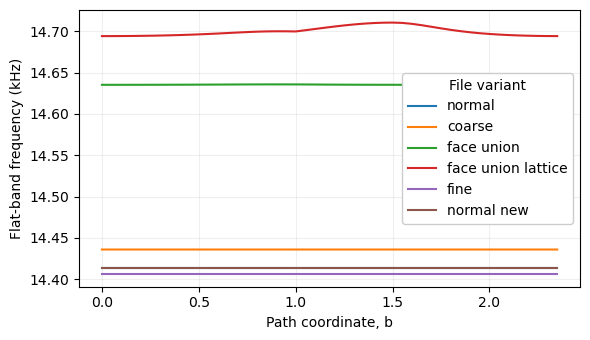

Flat-band metrics (highest of the 14 selected bands):
_: frequency=14.413364251 kHz, range=[14.413363916, 14.413364687] kHz, bandwidth=0.000771061323 Hz
_coarse_: frequency=14.435864557 kHz, range=[14.435862816, 14.435866705] kHz, bandwidth=0.00388908496 Hz
_face_union_: frequency=14.635410841 kHz, range=[14.635258988, 14.635789171] kHz, bandwidth=0.530183098 Hz
_face_union_lattice_: frequency=14.699995974 kHz, range=[14.694231091, 14.710614284] kHz, bandwidth=16.3831934 Hz
_fine_: frequency=14.406052473 kHz, range=[14.406052074, 14.406052883] kHz, bandwidth=0.000809245386 Hz
_normal_new_: frequency=14.413364251 kHz, range=[14.413363916, 14.413364687] kHz, bandwidth=0.000771061601 Hz


In [17]:
flat_band_metrics = {}

fig, ax = plt.subplots(figsize=(6, 3.5), tight_layout=True)
for label, dataset in band_data.items():
    flat_band_hz = dataset['bands_hz'][:, -1]
    flat_band_metrics[label] = {
        'mean_hz': flat_band_hz.mean(),
        'minimum_hz': flat_band_hz.min(),
        'maximum_hz': flat_band_hz.max(),
        'bandwidth_hz': np.ptp(flat_band_hz),
    }
    display_label = label.strip('_').replace('_', ' ') or 'normal'
    ax.plot(
        dataset['b'], flat_band_hz / 1e3,
        linewidth=1.5, label=display_label,
    )

ax.set_xlabel('Path coordinate, b')
ax.set_ylabel('Flat-band frequency (kHz)')
ax.grid(alpha=0.2)
handles, legend_labels = ax.get_legend_handles_labels()
legend = ax.legend(
    handles, legend_labels,
    title='File variant', loc='best',
    frameon=True, facecolor='white', framealpha=1.0,
    edgecolor='0.8',
)
legend.set_zorder(10)
plt.show()

print('Flat-band metrics (highest of the 14 selected bands):')
for label, metrics in flat_band_metrics.items():
    print(
        f'{label}: '
        f'frequency={metrics["mean_hz"] / 1e3:.9f} kHz, '
        f'range=[{metrics["minimum_hz"] / 1e3:.9f}, '
        f'{metrics["maximum_hz"] / 1e3:.9f}] kHz, '
        f'bandwidth={metrics["bandwidth_hz"]:.9g} Hz'
    )